# **Series de Tiempo — Regiones Geográficas**

## **Setup**

In [3]:
# Librerías
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kendalltau

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Configuraciones
warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

# Rutas y constantes
RAIZ = Path.cwd().parents[1] if Path.cwd().name == "series" else Path.cwd()
RUTA_TRAIN = RAIZ / "datos" / "processed" / "entrenamiento.csv"
RUTA_TEST = RAIZ / "datos" / "processed" / "prueba.csv"

PERIODO = 12  # estacionalidad mensual

print("Setup completado")

Setup completado


## **Distribución de los datos en las tres regiones**

Para poder distribuir el trabajo en las tres regiones con las que se van a construir las series, primero se identifican cuáles son las que más viajeros aportan durante todo el período de estudio, usando la variable `Región dos` y tomando como criterio el total acumulado de viajeros, tal como pide el enunciado. Cabe mencionar que, para calcular ese acumulado sobre la totalidad de los datos, se juntan el entrenamiento y la prueba únicamente con el fin de este ranking. A partir de la tabla se toman las tres primeras, es decir, América Del Centro, América Del Norte y Europa, que son las que se trabajarán como series de tiempo a lo largo del resto del notebook.

In [8]:
# Ranking de regiones por total de viajeros acumulado en todo el período (train + test).
entrenamiento = pd.read_csv(RUTA_TRAIN, parse_dates=["Fecha"])
prueba = pd.read_csv(RUTA_TEST, parse_dates=["Fecha"])
periodo_completo = pd.concat([entrenamiento, prueba], ignore_index=True)

ranking_regiones = (
    periodo_completo.groupby("Región dos")["Viajero"].sum()
    .sort_values(ascending=False)
    .round(0)
    .to_frame("viajeros_acumulados")
)
ranking_regiones.head(5)

,viajeros_acumulados
Región dos,
América Del Centro,33283932.0
América Del Norte,9160810.0
Europa,2149271.0
América Del Sur y el Caribe,1413590.0
Asia,410334.0


## **América del Centro**

#### **a. Especifique Inicio, fin, y frecuencia.**

La serie de entrenamiento va desde el 1 de enero de 2009 hasta el 1 de marzo de 2021. En cuanto a la frecuencia, cada observación representa un mes distinto, de tal forma que se trata de una serie mensual, y el total de observaciones que conforman el conjunto de entrenamiento es de 147.

In [9]:
# Serie mensual de América Del Centro (a partir del conjunto de entrenamiento).
serie_america_centro = (
    entrenamiento[entrenamiento["Región dos"] == "América Del Centro"]
    .groupby("Fecha")["Viajero"].sum()
    .asfreq("MS")
)

# a) Inicio, fin y frecuencia de la serie.
print("Inicio       :", serie_america_centro.index.min().date())
print("Fin          :", serie_america_centro.index.max().date())
print("Frecuencia   :", serie_america_centro.index.freqstr, "(mensual, inicio de mes)")
print("Observaciones:", serie_america_centro.shape[0])

Inicio       : 2009-01-01
Fin          : 2021-03-01
Frecuencia   : MS (mensual, inicio de mes)
Observaciones: 147


#### **b. Gráfico de la serie.**

A simple vista se observa una tendencia al crecimiento que se mantuvo de forma bastante constante desde 2009 hasta inicios de 2020, punto en el que llega la pandemia y, como es de esperarse, se registra una caída en picada en la cantidad de viajeros. Cabe mencionar que, con solo ver el gráfico, todavía no se puede afirmar con criterio si existe o no estacionalidad, de tal forma que eso se validará más adelante con la descomposición de la serie.

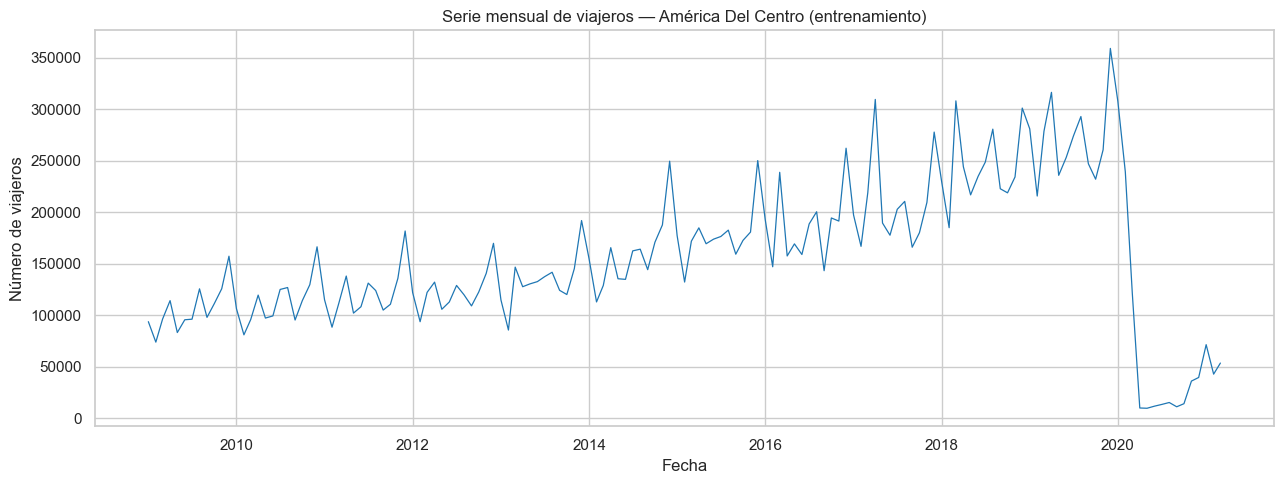

In [10]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_america_centro.index, serie_america_centro.values, color="tab:blue", linewidth=0.9)
ax.set_title("Serie mensual de viajeros — América Del Centro (entrenamiento)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Número de viajeros")
plt.tight_layout()
plt.show()

#### **c. Descomponga la serie.**

Entre la descomposición aditiva y la multiplicativa se opta por la multiplicativa, ya que en la serie original la amplitud de las oscilaciones estacionales no se mantiene constante sino que crece conforme sube el nivel, y además los residuos de la multiplicativa se mantienen más pegados alrededor de 1, mientras que los de la aditiva se van abriendo con el tiempo.

En cuanto a la tendencia, en ambas descomposiciones se evidencia claramente una tendencia al crecimiento, aunque cuando llega el 2020 cae en picada, tal como ya habíamos visto. En cuanto a la parte estacional, sí se observan ciertos patrones donde aparecen picos en puntos específicos y luego cae la cantidad de turismo, de tal forma que se puede afirmar que sí existe estacionalidad además de la tendencia. Respecto a los residuos, la mayoría se mantiene alrededor de un punto medio, a excepción de los correspondientes al 2020, que ya son parte de la pandemia.

En cuanto a la media móvil y la desviación móvil, aquí es donde probablemente vamos a tener inconvenientes, ya que ninguna de las dos se mantiene constante: la media móvil sube con los años y luego se desploma con la pandemia, y la desviación móvil no solo se dispara en 2020 sino que ya venía creciendo junto con el nivel de la serie desde antes. Bajo esta idea, en mi opinión diría que la serie no es estacionaria, ya que no observo que la media sea constante ni que la desviación lo sea, en parte por la tendencia y en parte por el fenómeno de la pandemia. Sin embargo, con las pruebas esto se podra validar.

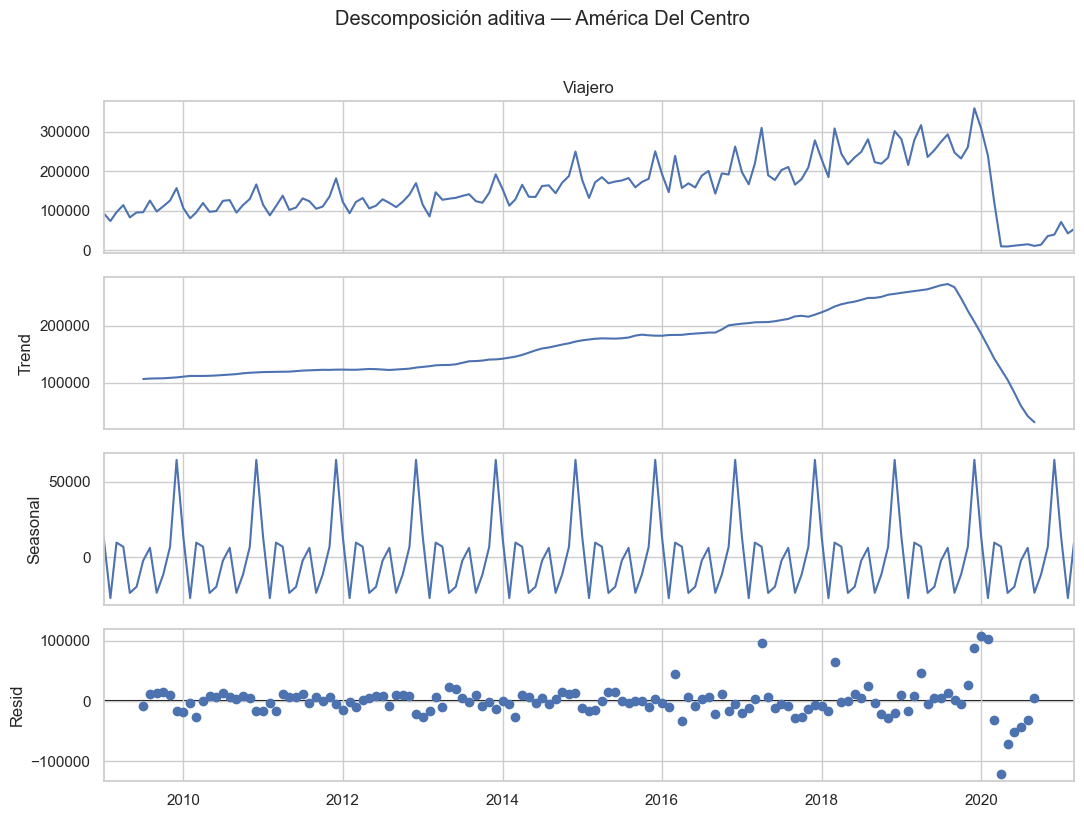

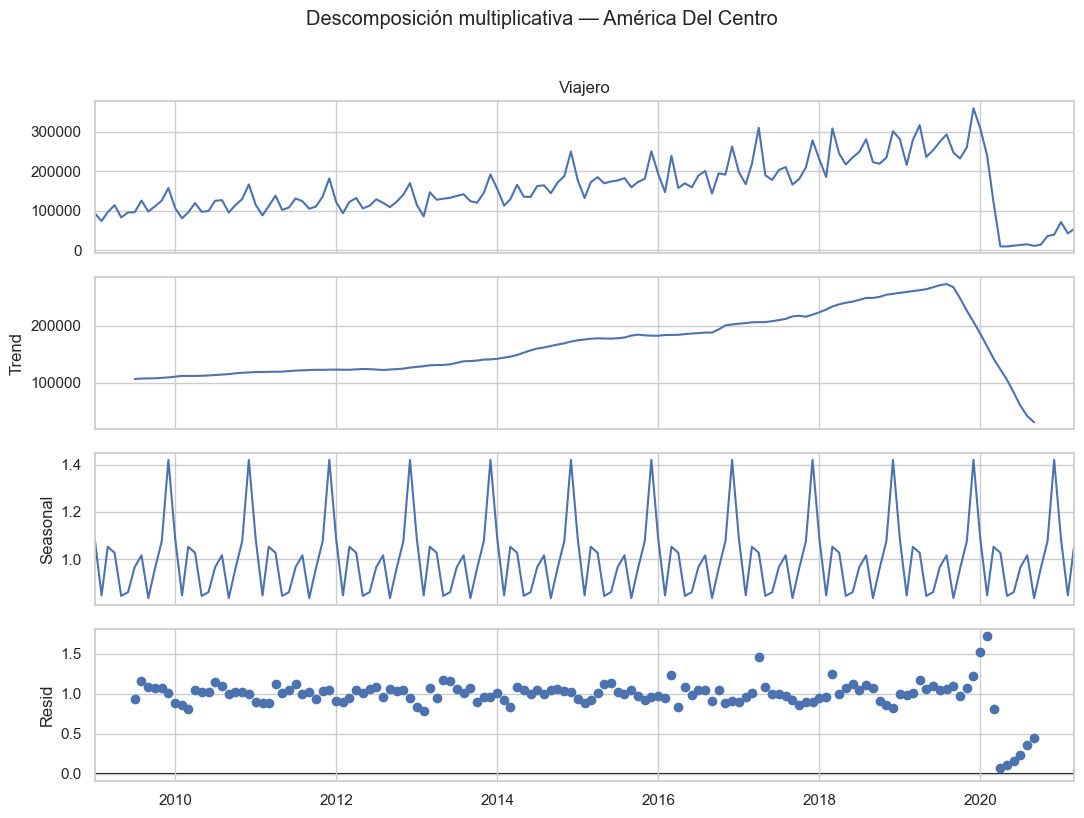

Desv. estándar del residuo aditivo       : 26297.255
Desv. estándar del residuo multiplicativo: 0.2053


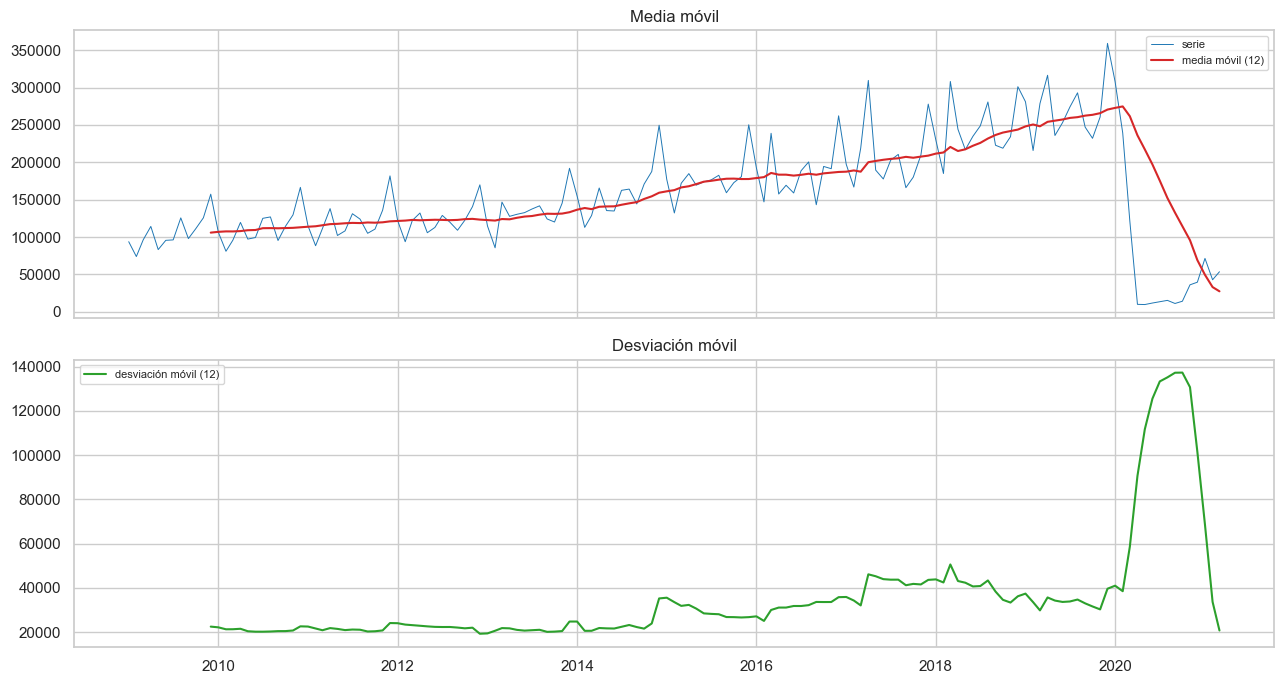

In [11]:
serie = serie_america_centro

# Descomposición en tendencia, estacionalidad y residuo (aditiva y multiplicativa).
desc_add = seasonal_decompose(serie, model="additive", period=PERIODO)
desc_mul = seasonal_decompose(serie, model="multiplicative", period=PERIODO)

fig = desc_add.plot()
fig.set_size_inches(11, 8)
fig.suptitle("Descomposición aditiva — América Del Centro", y=1.02)
plt.tight_layout()
plt.show()

fig = desc_mul.plot()
fig.set_size_inches(11, 8)
fig.suptitle("Descomposición multiplicativa — América Del Centro", y=1.02)
plt.tight_layout()
plt.show()

print("Desv. estándar del residuo aditivo       :", round(desc_add.resid.std(), 4))
print("Desv. estándar del residuo multiplicativo:", round(desc_mul.resid.std(), 4))

# Media y desviación móviles (ventana de 12) para evaluar si la media y la varianza son constantes.
media_movil = serie.rolling(PERIODO).mean()
desv_movil = serie.rolling(PERIODO).std()

fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax[0].plot(serie.index, serie.values, color="tab:blue", linewidth=0.7, label="serie")
ax[0].plot(media_movil.index, media_movil.values, color="tab:red", label="media móvil (12)")
ax[0].set_title("Media móvil")
ax[0].legend(fontsize=8)
ax[1].plot(desv_movil.index, desv_movil.values, color="tab:green", label="desviación móvil (12)")
ax[1].set_title("Desviación móvil")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

#### **d. Determine si es necesario transformar la serie.**

Sí, se considera necesario transformar la serie, y la transformación elegida es la logarítmica. La razón principal es que, tal como se vio en la descomposición, la varianza no es constante sino que crece conforme sube el nivel de la serie, lo cual se aprecia en el gráfico superior, donde las oscilaciones pasan de alrededor de 30 mil viajeros al inicio a más de 80 mil hacia 2019. Para validarlo se recurrió a la prueba de Box-Cox, y aquí cabe hacer una aclaración importante: sobre la serie completa el lambda resultó en 0.816, un valor cercano a 1 que sugeriría no transformar; sin embargo, esa estimación está distorsionada por el desplome de la pandemia, ya que los valores casi nulos de 2020 jalan el resultado. Cuando la prueba se calcula únicamente sobre el tramo normal (2009-2019), el lambda cae a -0.207, es decir, prácticamente 0, que corresponde justamente a la transformación logarítmica y concuerda con la descomposición multiplicativa elegida en el inciso anterior. Adicional, al comparar la desviación móvil antes y después del log, esta pasa de variar 2.63x a solo 1.87x, de tal forma que se confirma que el logaritmo estabiliza la varianza.

Box-Cox lambda (serie completa)         : 0.816
Box-Cox lambda (2009-2019, sin pandemia): -0.207

Desviación móvil (max/min en 2009-2019; menor = más constante):
  Serie original: 2.63x
  Serie log     : 1.87x


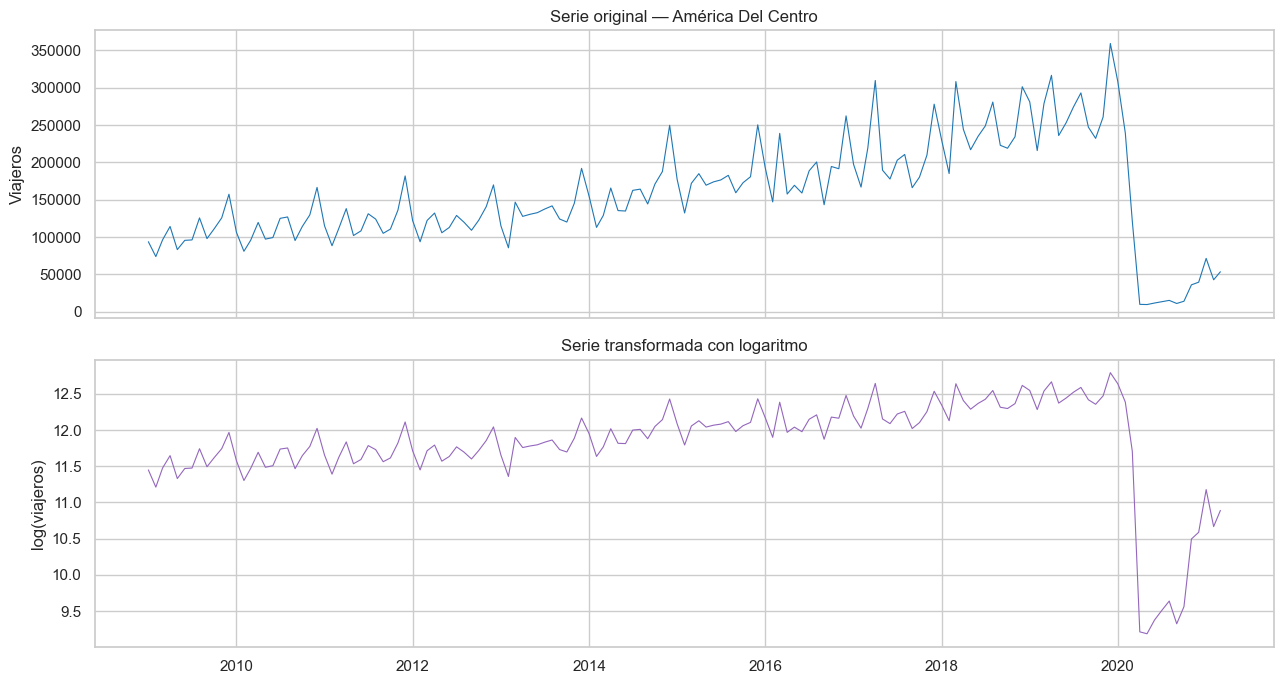

In [25]:
from scipy.stats import boxcox

# Prueba de Box-Cox para la transformación de varianza (lambda ≈0 => log, ≈0.5 => raíz, ≈1 => sin transformar).
_, lam_full = boxcox(serie_america_centro.values)
serie_pre_pandemia = serie_america_centro[serie_america_centro.index < "2020-03-01"]
_, lam_pre = boxcox(serie_pre_pandemia.values)
print(f"Box-Cox lambda (serie completa)         : {lam_full:.3f}")
print(f"Box-Cox lambda (2009-2019, sin pandemia): {lam_pre:.3f}")

# Serie transformada con logaritmo (candidata por la varianza que crece con el nivel).
serie_america_centro_log = np.log(serie_america_centro)

# Evidencia de estabilización: qué tan constante es la desviación móvil (12) antes vs después del log.
# Se mide en el tramo normal (2009-2019) para no confundirlo con el salto de la pandemia.
def ratio_desv_movil(s):
    dm = s[s.index < "2020-03-01"].rolling(PERIODO).std().dropna()
    return dm.max() / dm.min()

print(f"\nDesviación móvil (max/min en 2009-2019; menor = más constante):")
print(f"  Serie original: {ratio_desv_movil(serie_america_centro):.2f}x")
print(f"  Serie log     : {ratio_desv_movil(serie_america_centro_log):.2f}x")

# Comparación visual: original vs log (la log comprime el crecimiento de la amplitud estacional).
fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax[0].plot(serie_america_centro.index, serie_america_centro.values, color="tab:blue", linewidth=0.8)
ax[0].set_title("Serie original — América Del Centro")
ax[0].set_ylabel("Viajeros")
ax[1].plot(serie_america_centro_log.index, serie_america_centro_log.values, color="tab:purple", linewidth=0.8)
ax[1].set_title("Serie transformada con logaritmo")
ax[1].set_ylabel("log(viajeros)")
plt.tight_layout()
plt.show()

#### **e. Explique si no es estacionaria en media.**

Para analizar la estacionariedad en media se recurrió primero a la función de autocorrelación. En el gráfico se observa que la ACF decae de forma lenta, empezando en un valor alto cercano a 0.88 y bajando poco a poco hasta volverse no significativa. Este decaimiento lento es una señal clara de no estacionariedad por la media.

Para corroborarlo se aplicó la prueba de Dickey-Fuller Aumentada (ADF) sobre la serie transformada con logaritmo, y el p-valor resultó en 0.2003, es decir, mayor a 0.05, por lo que no se rechaza la hipótesis nula y se concluye en esta primera instancia que no es estacionaria, lo cual concuerda con lo que ya mostraba el ACF.

Para volverla estacionaria se debía diferenciar, y tras realizarlo una única vez el p-valor fue de 0.0358, por lo que en este caso ya se rechazó la hipótesis, indicador de que se ha llegado a que la serie sea estacionaria.

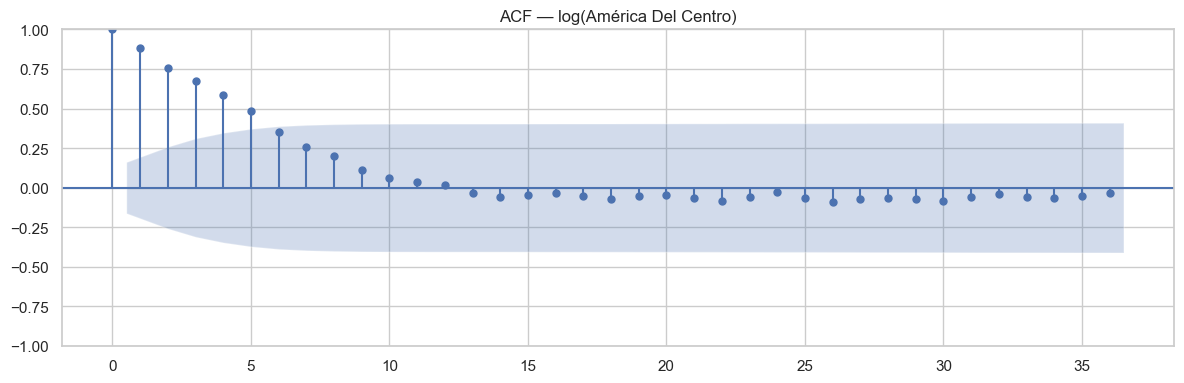

ADF log          estadístico= -2.216  p=0.2003  -> NO estacionaria
ADF log d=1      estadístico= -2.991  p=0.0358  -> estacionaria
ADF log d=1 D=1  estadístico= -6.274  p=0.0000  -> estacionaria


In [26]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(serie_america_centro_log.dropna(), lags=36, ax=ax)
ax.set_title("ACF — log(América Del Centro)")
plt.tight_layout()
plt.show()

def adf_test(x, nombre):
    r = adfuller(x.dropna(), autolag="AIC")
    print(f"ADF {nombre:12s} estadístico={r[0]:7.3f}  p={r[1]:.4f}  -> {'estacionaria' if r[1] < 0.05 else 'NO estacionaria'}")

adf_test(serie_america_centro_log, "log")


serie_america_centro_d1 = serie_america_centro_log.diff(1) 
serie_america_centro_d1D1 = serie_america_centro_log.diff(1).diff(PERIODO)
adf_test(serie_america_centro_d1, "log d=1")
adf_test(serie_america_centro_d1D1, "log d=1 D=1")

#### **f. Elección de los parámetros p, q y d.**

Antes de elegir los parámetros conviene aclarar que el modelo a utilizar es un SARIMA, ya que, como se vio en la descomposición, la serie cuenta tanto con tendencia como con estacionalidad.

En cuanto al orden de diferenciación, se retoma el trabajo del inciso anterior: al diferenciar la serie una única vez (d=1) ya se logró llegar a una serie estacionaria en media, por lo que se toma d=1 para la parte regular. Adicional, dado que existe una estacionalidad anual, se incorpora también una diferencia estacional (D=1, con s=12).

Para los órdenes p y q se analizan la ACF y la PACF de la serie ya diferenciada. En los primeros valores ni la ACF ni la PACF muestran picos significativos, es decir, se mantienen dentro de la banda, por lo que tanto la parte autorregresiva como la de media móvil no estacionales resultan nulas, quedando p=0 y q=0. Por otro lado, en el valor 12 la ACF sí muestra un pico negativo significativo que desaparece después, lo cual apunta a una media móvil estacional de orden 1 (Q=1), mientras que la PACF no sugiere una parte autorregresiva estacional (P=0). Bajo esta idea, el modelo del que se parte para predecir es un SARIMA(0,1,0)(0,1,1)[12].

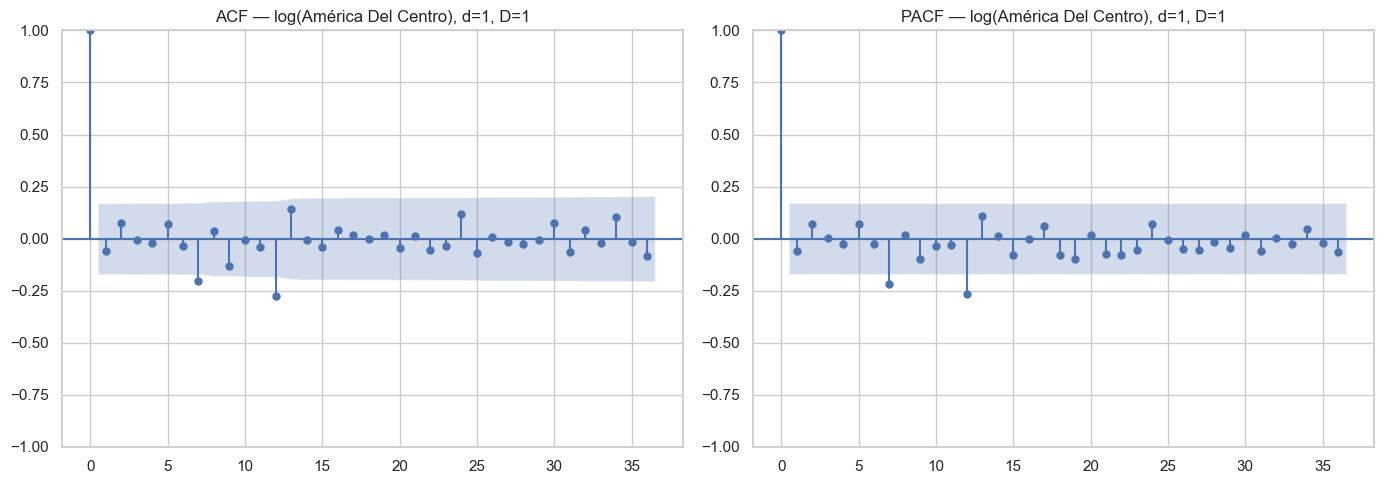

,valor
p,0
d,1
q,0
P,0
D,1
Q,1
s,12


In [27]:
# f) Derivación de los parámetros del SARIMA a partir de las pruebas y de la ACF/PACF.
s = PERIODO  # frecuencia estacional (mensual)

# d (diferencia regular): se diferencia hasta que la ADF indique estacionariedad en media.
d = 0
serie_tmp = serie_america_centro_log.dropna()
while adfuller(serie_tmp)[1] >= 0.05 and d < 2:
    serie_tmp = serie_tmp.diff().dropna()
    d += 1

# D (diferencia estacional): se aplica si tras la diferencia regular sigue habiendo
# correlación significativa en el lag estacional (s).
serie_d = serie_america_centro_log.diff(d).dropna()
D = 1 if abs(acf(serie_d, nlags=s)[s]) > 1.96 / np.sqrt(len(serie_d)) else 0

# Serie ya diferenciada (regular + estacional) para leer los órdenes con ACF y PACF.
serie_dif = serie_america_centro_log.diff(d)
if D:
    serie_dif = serie_dif.diff(s)
serie_dif = serie_dif.dropna()

banda = 1.96 / np.sqrt(len(serie_dif))
acf_v = acf(serie_dif, nlags=2 * s)
pacf_v = pacf(serie_dif, nlags=2 * s, method="ywm")
significativo = lambda v: abs(v) > banda

# p y q no estacionales: orden hasta donde la PACF (p) / ACF (q) deja de ser significativa.
def orden_corte(valores):
    orden = 0
    for k in range(1, s):
        if significativo(valores[k]):
            orden = k
        else:
            break
    return orden

p = orden_corte(pacf_v)
q = orden_corte(acf_v)

# P y Q estacionales: un pico único en el lag s que corta indica MA estacional (Q) o AR estacional (P).
if significativo(acf_v[s]) and not significativo(acf_v[2 * s]):
    P, Q = 0, 1
elif significativo(pacf_v[s]) and not significativo(pacf_v[2 * s]):
    P, Q = 1, 0
else:
    P, Q = 0, 0

# Gráficos de apoyo de la ACF y la PACF.
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(serie_dif, lags=36, ax=ax[0])
ax[0].set_title(f"ACF — log(América Del Centro), d={d}, D={D}")
plot_pacf(serie_dif, lags=36, ax=ax[1], method="ywm")
ax[1].set_title(f"PACF — log(América Del Centro), d={d}, D={D}")
plt.tight_layout()
plt.show()

# Tabla de parámetros del SARIMA, construida a partir de lo calculado arriba.
parametros_sarima = pd.DataFrame({"valor": [p, d, q, P, D, Q, s]},
                                 index=["p", "d", "q", "P", "D", "Q", "s"])
parametros_sarima

#### **g. Varios modelos SARIMA y elección del mejor.**

Analizando el AIC y el BIC se logra identificar que el segundo modelo es mejor que el establecido a través de los parámetros calculados manualmente, ya que en el primer modelo el AIC es de 53.87 mientras que en el segundo es de 49.25, y en cuanto al BIC el primer modelo tiene 59.67 frente a 55.04 del segundo. Cabe mencionar que ambos modelos tienen en realidad la misma cantidad de parámetros, es decir, un único término estacional cada uno, por lo que la ventaja del segundo no viene de ser más simple, sino de lograr un mejor ajuste con esa misma complejidad, y es por esto que gana tanto en AIC como en BIC.

Para complementar la elección se revisan los residuos. Con la prueba de Ljung-Box, cuya hipótesis nula plantea que los residuos no tienen autocorrelación, es decir, que se comportan como ruido blanco, se obtuvieron p-valores mayores a 0.05 en ambos modelos (en el segundo, 0.199 y 0.802 para los lags 12 y 24), por lo que no se rechaza la hipótesis nula y se concluye que a los residuos no les quedó estructura temporal sin capturar, lo cual indica un buen ajuste en los dos.

Esto también se aprecia en la matriz de diagnóstico del Modelo 2. En el gráfico de residuos en el tiempo los valores se mantienen alrededor de cero como si fueran ruido, salvo el pico pronunciado de 2020 que corresponde a la pandemia; en el correlograma, que es la versión visual del Ljung-Box, casi todas las barras caen dentro de la banda, confirmando la ausencia de autocorrelación. Por otro lado, el histograma muestra una distribución más apuntada que la normal, y el gráfico Q-Q sigue la recta en el centro pero se desvía en las colas, lo cual se debe justamente a ese valor atípico de la pandemia. De tal forma que los residuos son prácticamente ruido blanco y están centrados, aunque no perfectamente normales. Bajo esta idea, y dado que ambos modelos tienen residuos igual de limpios, la decisión se inclina por el Modelo 2, que es el que mejor puntúa en AIC y BIC.

In [28]:
# g) Modelo 1: el establecido en el inciso f a partir de la ACF/PACF.
modelo_1 = SARIMAX(serie_america_centro_log,
                   order=(p, d, q),
                   seasonal_order=(P, D, Q, s)).fit(disp=False)
print(f"Modelo 1: SARIMA({p},{d},{q})({P},{D},{Q})[{s}]  AIC={modelo_1.aic:.2f}  BIC={modelo_1.bic:.2f}")

Modelo 1: SARIMA(0,1,0)(0,1,1)[12]  AIC=53.87  BIC=59.67


In [29]:
# g) Modelo 2: búsqueda por AIC. Se fijan d, D y s (determinados en f) y se varían p, q, P, Q,
# quedándose con la combinación de menor AIC (equivalente a auto_arima; no se elige al azar).
import itertools

mejor = {"aic": np.inf, "order": None, "seasonal_order": None}
for pp, qq, PP, QQ in itertools.product(range(3), range(3), range(2), range(2)):
    try:
        m = SARIMAX(serie_america_centro_log,
                    order=(pp, d, qq),
                    seasonal_order=(PP, D, QQ, s)).fit(disp=False)
        if m.aic < mejor["aic"]:
            mejor = {"aic": m.aic, "order": (pp, d, qq), "seasonal_order": (PP, D, QQ, s)}
    except Exception:
        continue

modelo_2 = SARIMAX(serie_america_centro_log,
                   order=mejor["order"],
                   seasonal_order=mejor["seasonal_order"]).fit(disp=False)
print("Mejor orden por AIC:", mejor["order"], mejor["seasonal_order"])
print(f"Modelo 2: AIC={modelo_2.aic:.2f}  BIC={modelo_2.bic:.2f}")

Mejor orden por AIC: (0, 1, 0) (1, 1, 0, 12)
Modelo 2: AIC=49.25  BIC=55.04


,AIC,BIC
Modelo 1 (ACF/PACF),53.87,59.67
Modelo 2 (búsqueda AIC),49.25,55.04


Modelo 1 — Ljung-Box p-valores: lag 12 = 0.201, lag 24 = 0.768
Modelo 2 — Ljung-Box p-valores: lag 12 = 0.199, lag 24 = 0.802


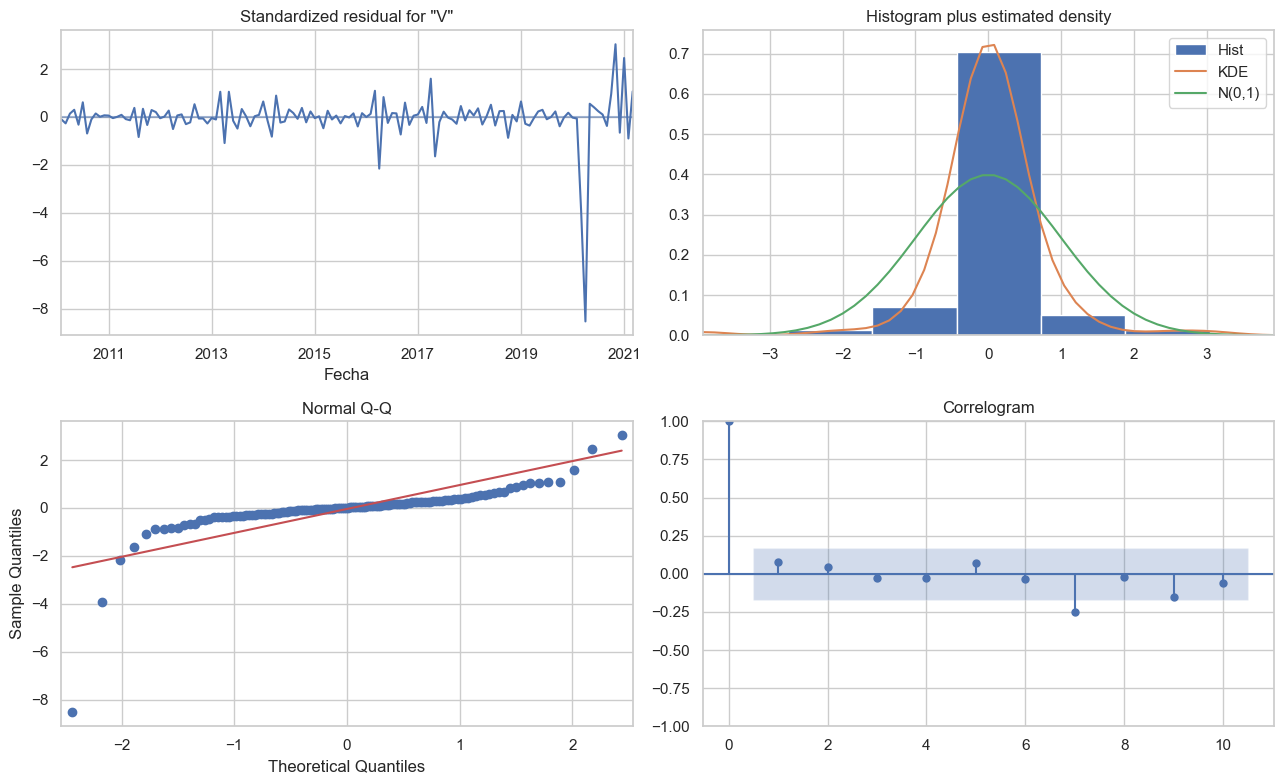

In [30]:
# g) Comparación de los dos modelos por AIC/BIC y análisis de residuos.
comparacion = pd.DataFrame({
    "AIC": [modelo_1.aic, modelo_2.aic],
    "BIC": [modelo_1.bic, modelo_2.bic],
}, index=["Modelo 1 (ACF/PACF)", "Modelo 2 (búsqueda AIC)"]).round(2)
display(comparacion)

# Ljung-Box sobre los residuos (p > 0.05 => sin autocorrelación => residuos tipo ruido blanco).
burn = d + s * D   # observaciones perdidas por la diferenciación (regular + estacional)
for nombre, modelo in [("Modelo 1", modelo_1), ("Modelo 2", modelo_2)]:
    resid = pd.Series(modelo.standardized_forecasts_error[0], index=serie_america_centro_log.index).iloc[burn:]
    lb = acorr_ljungbox(resid, lags=[12, 24], return_df=True)
    print(f"{nombre} — Ljung-Box p-valores: lag 12 = {lb['lb_pvalue'].iloc[0]:.3f}, lag 24 = {lb['lb_pvalue'].iloc[1]:.3f}")

# Diagnóstico visual de los residuos del Modelo 2 (el de menor AIC/BIC).
modelo_2.plot_diagnostics(figsize=(13, 8))
plt.tight_layout()
plt.show()

#### **h. Otros modelos y comparación.**

Para determinar el mejor modelo entre todos los que se entrenaron se utilizaron principalmente las métricas del error medio absoluto (MAE) y el RMSE, calculadas sobre el conjunto de prueba. Tras realizar la comparación, el mejor resultó ser el de suavizamiento exponencial simple, con un MAE de alrededor de 108,285 y un RMSE de 120,341, quedando por encima de Holt-Winters, del seasonal naive, y por encima también de Prophet y del propio SARIMA, que fueron los que peor se desempeñaron.

Este resultado puede deberse al lapso de tiempo que tomó el conjunto de entrenamiento, que justamente terminó en el desplome del turismo ocurrido durante la pandemia. Esto pudo generar que nuestros modelos SARIMA no se desempeñaran como probablemente se tenía anticipado, ya que se iba con la idea de que estos iban a ser mejores que los demás. De hecho, algo similar le ocurrió a Prophet, que quedó prácticamente empatado con el SARIMA en el fondo de la tabla, lo cual refuerza la idea de que los modelos que modelan explícitamente la tendencia terminan proyectando esa fuerte caída hacia adelante, mientras que un modelo más simple como el suavizamiento exponencial se mantiene en un nivel más estable y por eso termina acercándose más a los valores reales del período de prueba.

,MAE,RMSE
Suav. exp. simple,108285.0,120341.0
Holt-Winters,118481.0,129415.0
Seasonal naive,134400.0,144899.0
Prophet,153589.0,164392.0
SARIMA (Modelo 2),153057.0,164690.0


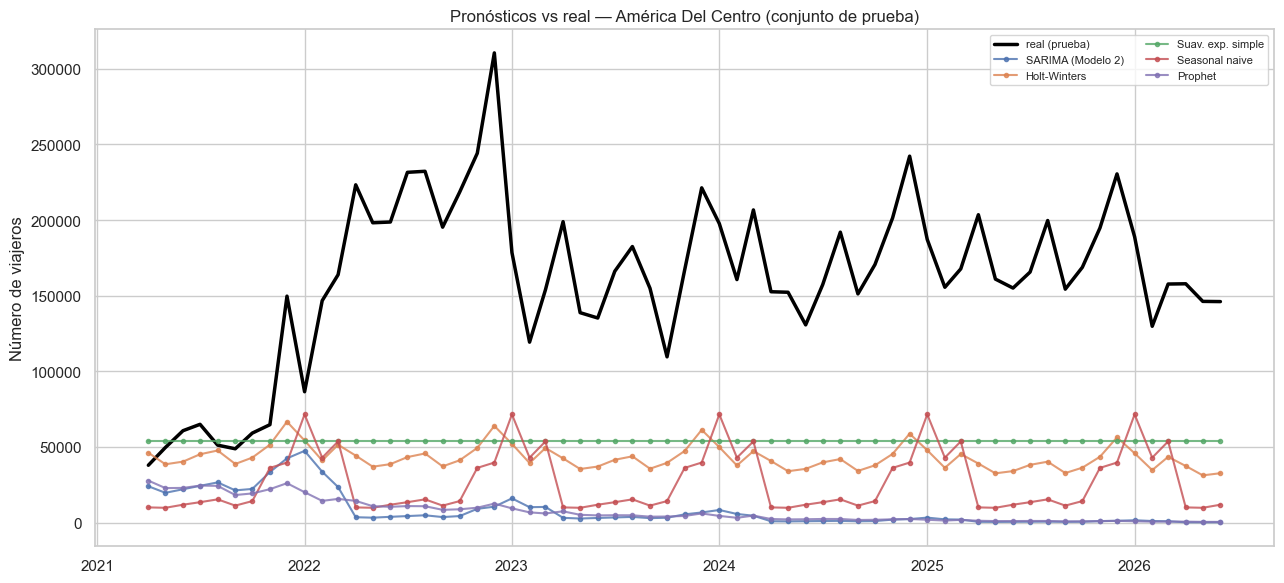

In [31]:
# h) Modelos alternativos sobre el train (log): Holt-Winters, suavizamiento exponencial simple, seasonal naive y Prophet.
import logging
logging.getLogger("cmdstanpy").setLevel(logging.CRITICAL)
from prophet import Prophet

serie_test_log = np.log(prueba[prueba["Región dos"] == "América Del Centro"].groupby("Fecha")["Viajero"].sum().asfreq("MS"))
H = len(serie_test_log)

hw = ExponentialSmoothing(serie_america_centro_log, trend="add", seasonal="add", seasonal_periods=s).fit()
ses = SimpleExpSmoothing(serie_america_centro_log).fit()

df_prophet = pd.DataFrame({"ds": serie_america_centro_log.index, "y": serie_america_centro_log.values})
modelo_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
modelo_prophet.fit(df_prophet)
pred_prophet = modelo_prophet.predict(pd.DataFrame({"ds": serie_test_log.index})).set_index("ds")["yhat"]

pronosticos = {
    "SARIMA (Modelo 2)": modelo_2.get_forecast(H).predicted_mean,
    "Holt-Winters": hw.forecast(H),
    "Suav. exp. simple": ses.forecast(H),
    "Seasonal naive": pd.Series(np.tile(serie_america_centro_log.iloc[-s:].values, int(np.ceil(H / s)))[:H],
                                index=serie_test_log.index),
    "Prophet": pred_prophet,
}

# Métricas fuera de muestra en la escala original (se deshace el log con exp).
def metricas(y_true_log, y_pred_log):
    y_true, y_pred = np.exp(y_true_log), np.exp(np.asarray(y_pred_log))
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return mae, rmse

comparacion_h = pd.DataFrame(
    {nombre: dict(zip(["MAE", "RMSE"], metricas(serie_test_log.values, p.values))) for nombre, p in pronosticos.items()}
).T.round(0).sort_values("RMSE")
display(comparacion_h)

# Gráfico: real vs cada pronóstico (escala original).
real = np.exp(serie_test_log)
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(real.index, real.values, color="black", linewidth=2.5, label="real (prueba)")
for nombre, p in pronosticos.items():
    ax.plot(p.index, np.exp(np.asarray(p.values)), marker=".", alpha=0.8, label=nombre)
ax.set_title("Pronósticos vs real — América Del Centro (conjunto de prueba)")
ax.set_ylabel("Número de viajeros")
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

#### **i. Predicción con el mejor modelo.**

Con el mejor modelo, es decir, el de suavizamiento exponencial simple, se proyectan los valores de la serie sobre el conjunto de prueba y, adicional, se extiende la predicción hasta el año 2027. Para validar qué tan bien le fue se comparan estos valores contra los reales, y como se aprecia en el gráfico y en la tabla de totales anuales, el modelo se queda bastante corto: proyecta un nivel prácticamente plano de alrededor de 643,877 viajeros al año para todos los años, mientras que en la realidad los años posteriores a la pandemia rondaron los 2 millones, con 2,449,578 en 2022, 2,115,335 en 2024 y 2,143,694 en 2025.

Esto no hace mucho sentido lógico como proyección de la recuperación del turismo, ya que el suavizamiento exponencial simple simplemente extiende hacia adelante el último nivel del entrenamiento, que quedó deprimido por la pandemia, y por eso no logra capturar el crecimiento que sí ocurrió. En otras palabras, aunque fue el mejor de todos, lo fue solo en términos relativos, al equivocarse menos que los demás, pero al revisar los datos reales, su desempeño es bastante malo, no algo que se pondría en producción.

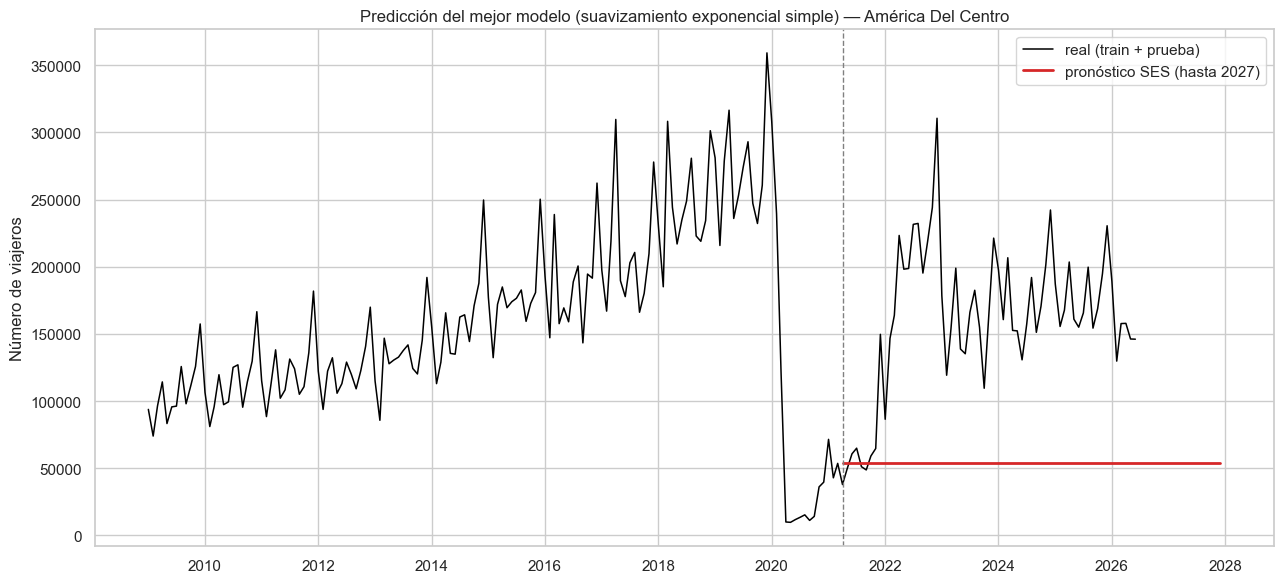

,real,predicho_SES
2022,2449578.0,643877.0
2023,1926018.0,643877.0
2024,2115335.0,643877.0
2025,2143694.0,643877.0
2026,926638.0,643877.0
2027,NaN,643877.0


In [32]:
# i) Predicción con el mejor modelo (suavizamiento exponencial simple), extendida hasta 2027.
serie_real = pd.concat([np.exp(serie_america_centro_log), np.exp(serie_test_log)])
indice_futuro = pd.date_range("2021-04-01", "2027-12-01", freq="MS")
pronostico_ses = np.exp(pd.Series(ses.forecast(len(indice_futuro)).values, index=indice_futuro))

# Gráfico: real (train + prueba) vs pronóstico del mejor modelo.
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(serie_real.index, serie_real.values, color="black", linewidth=1.1, label="real (train + prueba)")
ax.plot(pronostico_ses.index, pronostico_ses.values, color="tab:red", linewidth=2, label="pronóstico SES (hasta 2027)")
ax.axvline(pd.Timestamp("2021-04-01"), color="gray", linestyle="--", linewidth=1)
ax.set_title("Predicción del mejor modelo (suavizamiento exponencial simple) — América Del Centro")
ax.set_ylabel("Número de viajeros")
ax.legend()
plt.tight_layout()
plt.show()

# Total anual de viajeros: real vs predicho (mismo criterio de acumulado anual usado en el ranking).
totales_anuales = pd.DataFrame({
    "real": serie_real.groupby(serie_real.index.year).sum(),
    "predicho_SES": pronostico_ses.groupby(pronostico_ses.index.year).sum(),
}).loc[[2022, 2023, 2024, 2025, 2026, 2027]].round(0)
display(totales_anuales)

#### **j. Comparación de modelos por métricas.**

En esta sección se consolidan las métricas de todos los modelos en dos tablas. La primera compara el MAE y el RMSE de todos los modelos entrenados, incluyendo ambos modelos SARIMA, y la segunda muestra el AIC y el BIC de esos dos SARIMA. Cabe mencionar que estas métricas ya se discutieron previamente: el AIC y el BIC en el inciso g, donde el Modelo 2 resultó mejor que el Modelo 1, y el MAE y el RMSE en el inciso h, donde el suavizamiento exponencial simple resultó el mejor de todos y los modelos SARIMA quedaron en el fondo.

In [33]:
# j) Tabla 1: MAE y RMSE de todos los modelos, incluyendo ambos SARIMA.
pronosticos_j = dict(pronosticos)
pronosticos_j["SARIMA (Modelo 1)"] = modelo_1.get_forecast(H).predicted_mean
tabla_errores = pd.DataFrame(
    {nombre: dict(zip(["MAE", "RMSE"], metricas(serie_test_log.values, p.values))) for nombre, p in pronosticos_j.items()}
).T.round(0).sort_values("RMSE")
display(tabla_errores)

# j) Tabla 2: AIC y BIC de los dos modelos SARIMA.
tabla_ic = pd.DataFrame({
    "AIC": [modelo_1.aic, modelo_2.aic],
    "BIC": [modelo_1.bic, modelo_2.bic],
}, index=["SARIMA (Modelo 1)", "SARIMA (Modelo 2)"]).round(2)
display(tabla_ic)

,MAE,RMSE
Suav. exp. simple,108285.0,120341.0
Holt-Winters,118481.0,129415.0
Seasonal naive,134400.0,144899.0
SARIMA (Modelo 1),149143.0,159902.0
Prophet,153589.0,164392.0
SARIMA (Modelo 2),153057.0,164690.0


,AIC,BIC
SARIMA (Modelo 1),53.87,59.67
SARIMA (Modelo 2),49.25,55.04


#### **k. Selección del mejor modelo.**

Con base en las métricas encontradas en el inciso j, los modelos que presentan mejores resultados son los ajenos a los ARIMA. Entre todos los modelos, el mejor fue el de suavizamiento exponencial simple, con un MAE de alrededor de 108,285 y un RMSE de 120,341. Este probablemente salió mejor debido a que en el conjunto de entrenamiento se encuentra la pandemia, de tal forma que los modelos que se enfocan en aprender tendencias o este tipo de patrones, como el SARIMA y Prophet, terminaron asumiendo el pico de caída del 2020 y parte del 2021, donde hubo una decadencia total del turismo, y lo proyectaron hacia adelante, mientras que los modelos más simples se mantuvieron en un nivel más estable y por eso se acercaron más a los valores reales.

## **América del Norte**

#### **a. Especifique Inicio, fin, y frecuencia.**

Al igual que en la serie anterior, la serie de entrenamiento de América del Norte va desde el 1 de enero de 2009 hasta el 1 de marzo de 2021, con una frecuencia mensual, es decir, cada observación representa un mes distinto, para un total de 147 observaciones.

Cabe mencionar que esta serie presentaba 5 meses sin registros, correspondientes al período de abril a agosto de 2020, que fue justamente el cierre de la pandemia. Bajo mi perspectiva, la ruta válida para tratar estos meses es rellenarlos con un valor bajo, dado que durante ese tiempo los valores realmente tendrían que ser cero, ya que los aeropuertos estaban totalmente cerrados y no había conexión con el exterior. Al tomar un valor bajo, en este caso el mínimo observado de la serie, evitamos inducir datos más raros o distintos de la realidad, y a la vez mantenemos la serie continua sin caer en ceros que impedirían la transformación logarítmica.

In [34]:
# Serie mensual de América Del Norte (a partir del conjunto de entrenamiento).
serie_america_norte = (
    entrenamiento[entrenamiento["Región dos"] == "América Del Norte"]
    .groupby("Fecha")["Viajero"].sum()
    .asfreq("MS")
)

# Los 5 meses del cierre pandémico (abr-ago 2020) vienen sin registros (arribos ~0 por aeropuertos cerrados).
# Se rellenan con el valor mínimo observado de la serie, para mantenerla continua sin inducir ceros.
meses_faltantes = serie_america_norte.index[serie_america_norte.isna()]
valor_relleno = serie_america_norte.min()
serie_america_norte = serie_america_norte.fillna(valor_relleno)

# a) Inicio, fin, frecuencia y detalle del relleno.
print("Meses rellenados:", len(meses_faltantes), "->", ", ".join(m.strftime("%Y-%m") for m in meses_faltantes))
print("Valor de relleno (mínimo de la serie):", round(valor_relleno))
print("Inicio       :", serie_america_norte.index.min().date())
print("Fin          :", serie_america_norte.index.max().date())
print("Frecuencia   :", serie_america_norte.index.freqstr, "(mensual, inicio de mes)")
print("Observaciones:", serie_america_norte.shape[0])

Meses rellenados: 5 -> 2020-04, 2020-05, 2020-06, 2020-07, 2020-08
Valor de relleno (mínimo de la serie): 1144
Inicio       : 2009-01-01
Fin          : 2021-03-01
Frecuencia   : MS (mensual, inicio de mes)
Observaciones: 147


#### **b. Gráfico de la serie.**

Tras analizar el gráfico de la serie, y de forma similar a lo visto en América Central, desde el punto de comienzo de los datos de entrenamiento hasta 2019 se nota una tendencia creciente. La estacionalidad a simple vista no se puede determinar, por lo que esto se establecerá más adelante con la descomposición y las pruebas adicionales. De la misma forma, después de la llegada de la pandemia el gráfico cae por completo, pasando de un pico en 2019 a un valle bastante bajo. Cabe mencionar que ese valle es en parte inducido, ya que corresponde a los cinco meses que no tenían registro y que se rellenaron con un valor bajo cercano a mil, esto para no dejarlo en cero y así poder aplicar la transformación logarítmica más adelante. Finalmente, después de esos cinco meses se evidencia un crecimiento lento en la cantidad de viajeros.

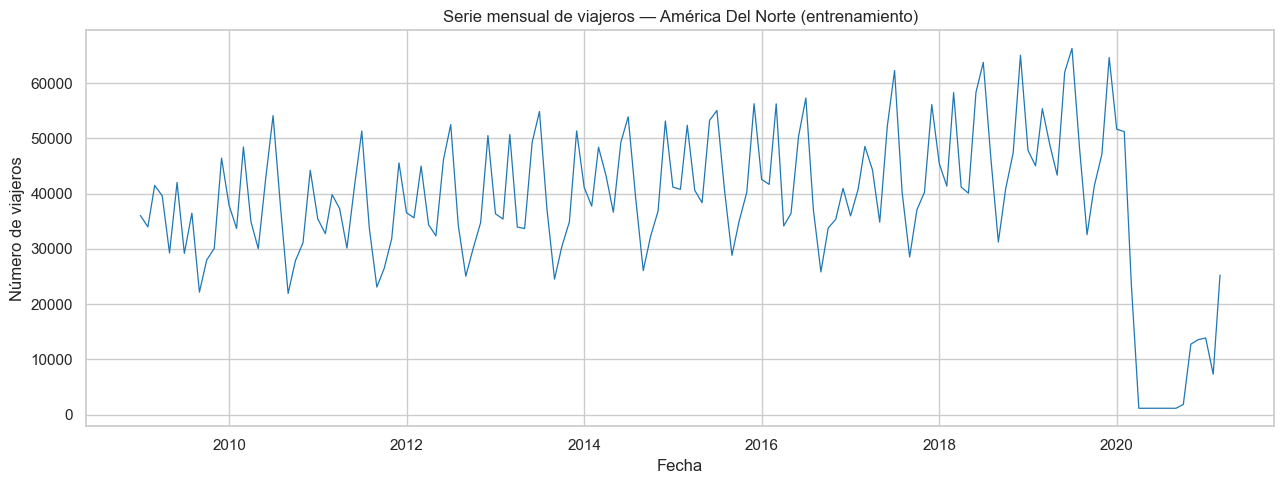

In [35]:
# b) Gráfico de la serie mensual de América Del Norte.
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_america_norte.index, serie_america_norte.values, color="tab:blue", linewidth=0.9)
ax.set_title("Serie mensual de viajeros — América Del Norte (entrenamiento)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Número de viajeros")
plt.tight_layout()
plt.show()

#### **c. Descomponga la serie.**

En cuanto a la elección entre la descomposición aditiva y la multiplicativa, se opta por la multiplicativa. Para no basar esta decisión únicamente en lo visual, se recurre al lambda de Box-Cox, que es el criterio objetivo para esto: un valor cercano a 1 indica una serie aditiva, es decir, con varianza constante, y un valor cercano a 0 indica una multiplicativa, con varianza que crece con el nivel. En este caso el lambda resultó en 0.229, más cerca de 0 que de 1, lo cual respalda la elección multiplicativa, aunque cabe mencionar que aquí la decisión es más ajustada que en América Central, donde el lambda era prácticamente 0 y por lo tanto la serie era multiplicativa de forma mucho más contundente.

En cuanto a la tendencia, se identifica una tendencia creciente, aunque cabe recalcar que se nota una diferencia respecto a América Central, y es que aquí la tendencia crece a un ritmo menor. No obstante, en ambos casos se observa que desde 2019 hasta 2020, tras la llegada de la pandemia, la serie cae rotundamente desde el pico en el que se encontraba hasta un valle bastante bajo.

En cuanto a la estacionalidad, se logra identificar un patrón que se repite cada año, con varios picos y un valle marcado dentro del ciclo, lo cual confirma que sí existe estacionalidad además de la tendencia.

Finalmente, en cuanto a la media móvil y la desviación móvil, no se evidencia que ninguna de las dos sea constante: la media móvil crece con los años y luego se desploma con la pandemia, mientras que la desviación móvil se mantiene relativamente estable pero termina disparándose tras la pandemia, lo cual tiene sentido ya que los valores llegaron a ser prácticamente inexistentes. Bajo esta idea, se concluye que la serie no es estacionaria, ni en media ni en varianza.

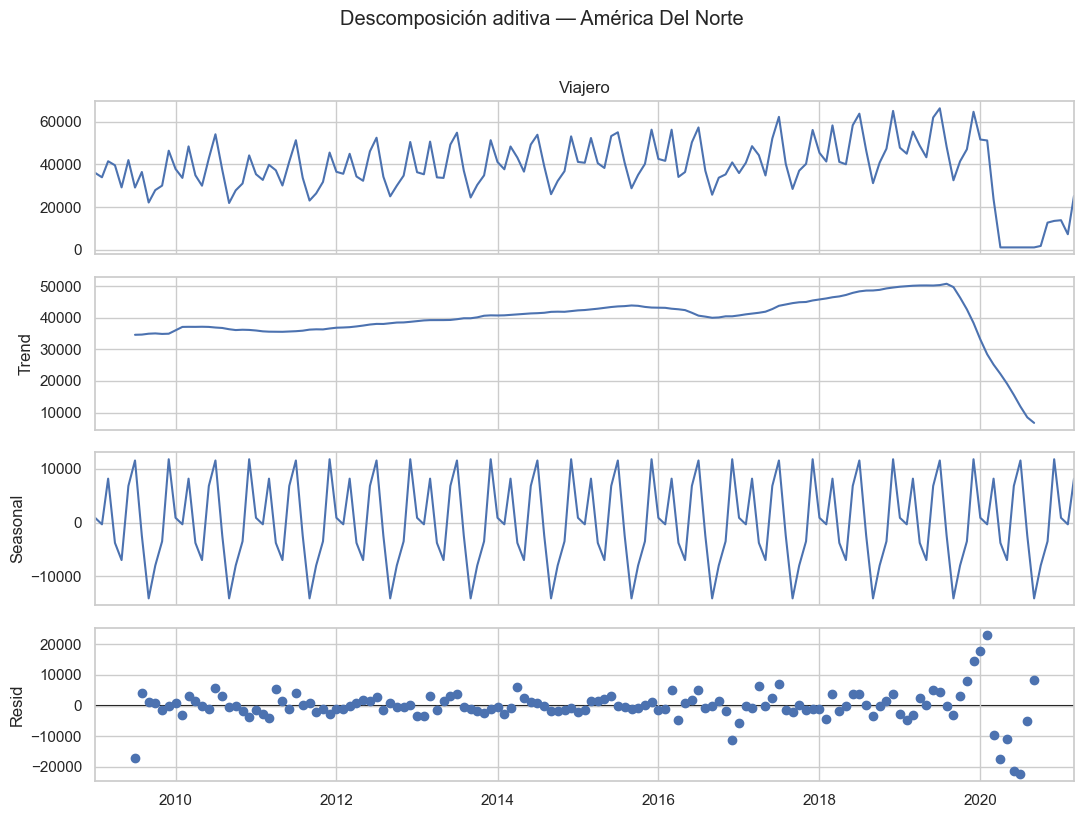

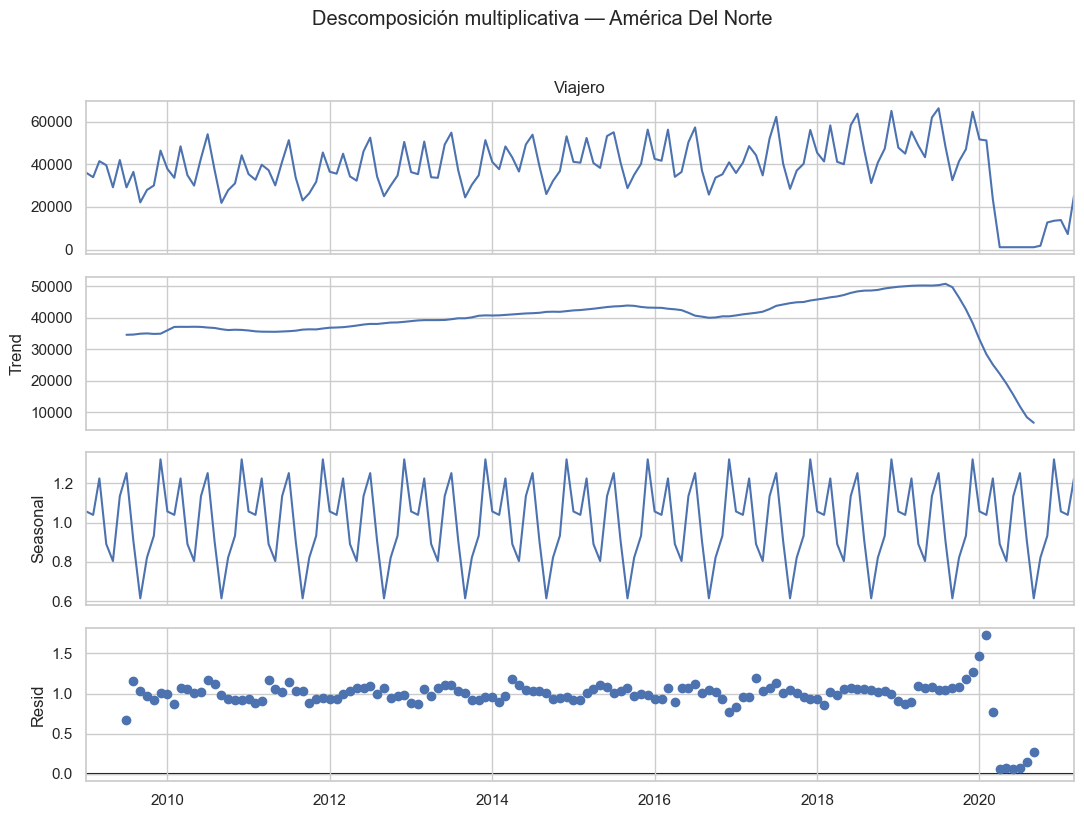

Desv. estándar del residuo aditivo       : 5388.5183
Desv. estándar del residuo multiplicativo: 0.2191


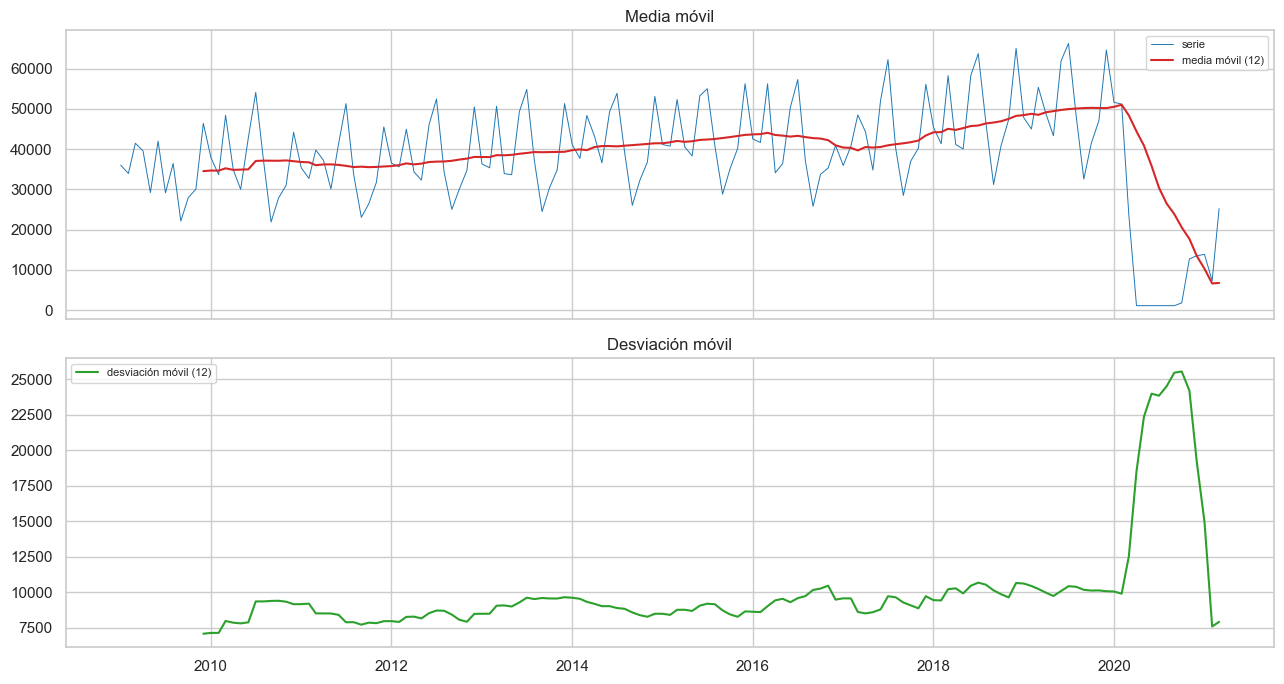

In [36]:
serie = serie_america_norte

# Descomposición en tendencia, estacionalidad y residuo (aditiva y multiplicativa).
desc_add = seasonal_decompose(serie, model="additive", period=PERIODO)
desc_mul = seasonal_decompose(serie, model="multiplicative", period=PERIODO)

fig = desc_add.plot()
fig.set_size_inches(11, 8)
fig.suptitle("Descomposición aditiva — América Del Norte", y=1.02)
plt.tight_layout()
plt.show()

fig = desc_mul.plot()
fig.set_size_inches(11, 8)
fig.suptitle("Descomposición multiplicativa — América Del Norte", y=1.02)
plt.tight_layout()
plt.show()

# Criterio objetivo aditiva vs multiplicativa: lambda de Box-Cox (~1 aditiva, ~0 multiplicativa).
# Se calcula sobre el tramo normal (2009-2019) para no distorsionarlo con la pandemia.
from scipy.stats import boxcox
_, lambda_boxcox = boxcox(serie[serie.index < "2020-03-01"].values)
print(f"Lambda de Box-Cox (2009-2019): {lambda_boxcox:.3f}   (~1 aditiva, ~0 multiplicativa)")

# Media y desviación móviles (ventana de 12) para evaluar si la media y la varianza son constantes.
media_movil = serie.rolling(PERIODO).mean()
desv_movil = serie.rolling(PERIODO).std()

fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax[0].plot(serie.index, serie.values, color="tab:blue", linewidth=0.7, label="serie")
ax[0].plot(media_movil.index, media_movil.values, color="tab:red", label="media móvil (12)")
ax[0].set_title("Media móvil")
ax[0].legend(fontsize=8)
ax[1].plot(desv_movil.index, desv_movil.values, color="tab:green", label="desviación móvil (12)")
ax[1].set_title("Desviación móvil")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## **Europa**